# 📈 线性回归 Linear Regression

> 线性回归是机器学习中最简单的算法，可以通过不同的方法进行训练。在本课程中，我们将涵盖以下线性算法:

> 1. 线性回归        Linear Regression
> 2. 岭回归         Ridge Regression
> 3. 罗素回归        LASSO Regression
> 4. 弹性网络        Elastic Net
> 5. 多项式回归       Polynomial Regression
> 6. 随机梯度下降     Stochastic Gradient Descent
> 7. 人工神经网络     Artificial Neaural Networks
> 8. 随机森林         Random forest
> 9. 支持向量机       Support Vector Machine

# 💾 数据集介绍

> 本课程将使用在线股票数据。由于股票价格是一个连续变量，是一个典型的回归问题。数据包含以下特征:

## pro_api 接口数据
> * '`ts_code`':        股票代码
> * '`trade_date`':     交易日期
> * '`open`':           开盘价
> * '`high`':           最高价
> * '`low`':            最低价
> * '`close`':          收盘价
> * '`pre_close`':      昨收价
> * '`change`':         涨跌额
> * '`pct_chg`':        涨跌幅
> * '`vol`':            成交量 （手）
> * '`amount`':         成交额 （千元）


## get_hist_data 接口数据
> * '`date`':           交易日期
> * '`open`':           开盘价
> * '`high`':           最高价
> * '`low`':            最低价
> * '`close`':          收盘价
> * '`price_change`':   涨跌额
> * '`p_change`':       涨跌幅
> * '`ma5`':            5日均价
> * '`ma10`':           10日均价
> * '`ma20`':           20日均价
> * '`v_ma5`':          5日均量
> * '`v_ma10`':         10日均量
> * '`v_ma20`':         20日均量
> * '`volume`':         成交量
> * '`turnover`':       换手率

# 📤 库导入

In [1]:
# 核心工具库
import pandas as pd
import numpy as np

# 画图分析库
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

# 数据采集库
import tushare as ts

# 其他设置
%matplotlib inline
sns.set_style("whitegrid")

## 💾 数据获取

In [2]:
ts_code = '300033.SZ'

df_old = ts.get_hist_data('300033')
# 获取数据
pro = ts.pro_api('90ebe1169771a7a44ff42d7afb61e243f257ff653fc1c2d10af45410')
df = pro.daily(ts_code=ts_code)   # 一次性获取全部日k线数据

# 获取指定起止日期的股票数据
# df = pro.daily(ts_code='000001.SZ', trade_date='20180701', start_date='20180701', end_date='20180718')

# 查看数据

本接口即将停止更新，请尽快使用Pro版接口：https://waditu.com/document/2


In [3]:
df.head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,300033.SZ,20210908,132.60,145.52,131.58,137.31,134.92,2.39,1.7714,180999.77,2521723.159
1,300033.SZ,20210907,126.05,135.13,124.28,134.92,126.04,8.88,7.0454,172134.68,2249430.285
2,300033.SZ,20210906,118.00,129.38,118.00,126.04,119.15,6.89,5.7826,154807.42,1939889.061
3,300033.SZ,20210903,129.99,130.00,118.86,119.15,122.35,-3.20,-2.6154,147114.78,1822468.141
4,300033.SZ,20210902,120.20,124.00,119.01,122.35,121.12,1.23,1.0155,140304.99,1714626.369


## 💾 数据保存

In [4]:
# 创建文件
filename = './Dataset/' + ts_code + '.csv'
filename_old = './Dataset/' + ts_code + '_old.csv'

# 写入数据
df = df.drop(columns=['ts_code', 'trade_date'])
df.to_csv(filename, mode="w")
df.head()

df_old.to_csv(filename_old)

## 💾 检查数据

In [5]:
ts_data = pd.read_csv(filename)
print("+++++++++++++++++++++++++数据特征信息+++++++++++++++++++++++++++")
print(ts_data.columns)
print("+++++++++++++++++++++++++数据类型信息+++++++++++++++++++++++++++")
ts_data.info()
print("+++++++++++++++++++++++++数据基本信息+++++++++++++++++++++++++++")
ts_data.describe()

+++++++++++++++++++++++++数据特征信息+++++++++++++++++++++++++++
Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'pre_close', 'change',
       'pct_chg', 'vol', 'amount'],
      dtype='object')
+++++++++++++++++++++++++数据类型信息+++++++++++++++++++++++++++
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2827 entries, 0 to 2826
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2827 non-null   int64  
 1   open        2827 non-null   float64
 2   high        2827 non-null   float64
 3   low         2827 non-null   float64
 4   close       2827 non-null   float64
 5   pre_close   2827 non-null   float64
 6   change      2827 non-null   float64
 7   pct_chg     2827 non-null   float64
 8   vol         2827 non-null   float64
 9   amount      2827 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 221.0 KB
+++++++++++++++++++++++++数据基本信息+++++++++++++++++++++++++++


,Unnamed: 0,open,high,low,close,pre_close,change,pct_chg,vol,amount
count,2827.00000,2827.000000,2827.000000,2827.000000,2827.000000,2827.000000,2827.000000,2827.000000,2827.000000,2.827000e+03
mean,1413.00000,59.559186,61.229614,58.297372,59.770258,59.686339,0.083919,0.176111,65145.186689,5.286638e+05
std,816.22893,38.695507,39.870341,37.814389,38.817068,38.735607,2.784213,3.641717,67727.049524,6.904224e+05
min,0.00000,11.810000,12.180000,11.800000,12.010000,12.010000,-15.090000,-10.048500,1522.800000,2.343902e+03
25%,706.50000,24.505000,25.040000,24.010000,24.590000,24.540000,-0.765000,-1.676250,15382.535000,4.328901e+04
50%,1413.00000,50.500000,51.820000,49.900000,50.900000,50.800000,0.010000,0.010000,43145.960000,2.109406e+05
75%,2119.50000,83.355000,86.890000,81.530000,84.000000,83.950000,0.710000,1.680000,92425.855000,7.823201e+05
max,2826.00000,179.000000,187.990000,171.100000,178.610000,178.610000,21.220000,33.300000,691945.200000,4.376327e+06


In [6]:
ts_data_old = pd.read_csv(filename_old)
ts_data_old = ts_data_old[["p_change", "close", "volume", "v_ma5"]]
print("+++++++++++++++++++++++++数据信息处理+++++++++++++++++++++++++++")
print("+++++++++++++++++++++++++数据特征信息+++++++++++++++++++++++++++")
print(ts_data_old.columns)
print("+++++++++++++++++++++++++数据类型信息+++++++++++++++++++++++++++")
ts_data_old.info()
print("+++++++++++++++++++++++++数据基本信息+++++++++++++++++++++++++++")
ts_data_old.describe()

+++++++++++++++++++++++++数据信息处理+++++++++++++++++++++++++++
+++++++++++++++++++++++++数据特征信息+++++++++++++++++++++++++++
Index(['p_change', 'close', 'volume', 'v_ma5'], dtype='object')
+++++++++++++++++++++++++数据类型信息+++++++++++++++++++++++++++
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   p_change  613 non-null    float64
 1   close     613 non-null    float64
 2   volume    613 non-null    float64
 3   v_ma5     613 non-null    float64
dtypes: float64(4)
memory usage: 19.3 KB
+++++++++++++++++++++++++数据基本信息+++++++++++++++++++++++++++


,p_change,close,volume,v_ma5
count,613.000000,613.000000,613.000000,613.000000
mean,0.149592,116.776770,101707.678303,101733.223377
std,3.544373,21.867234,51969.587821,41000.452901
min,-10.050000,76.910000,25.000000,34210.980000
25%,-1.760000,99.660000,62187.190000,68686.050000
50%,-0.150000,113.410000,87496.010000,93633.110000
75%,1.460000,129.730000,131752.420000,127369.920000
max,17.860000,178.610000,300376.120000,231466.220000


# 📊 探索性数据分析 (Exploratory Data Analysis, EDA)

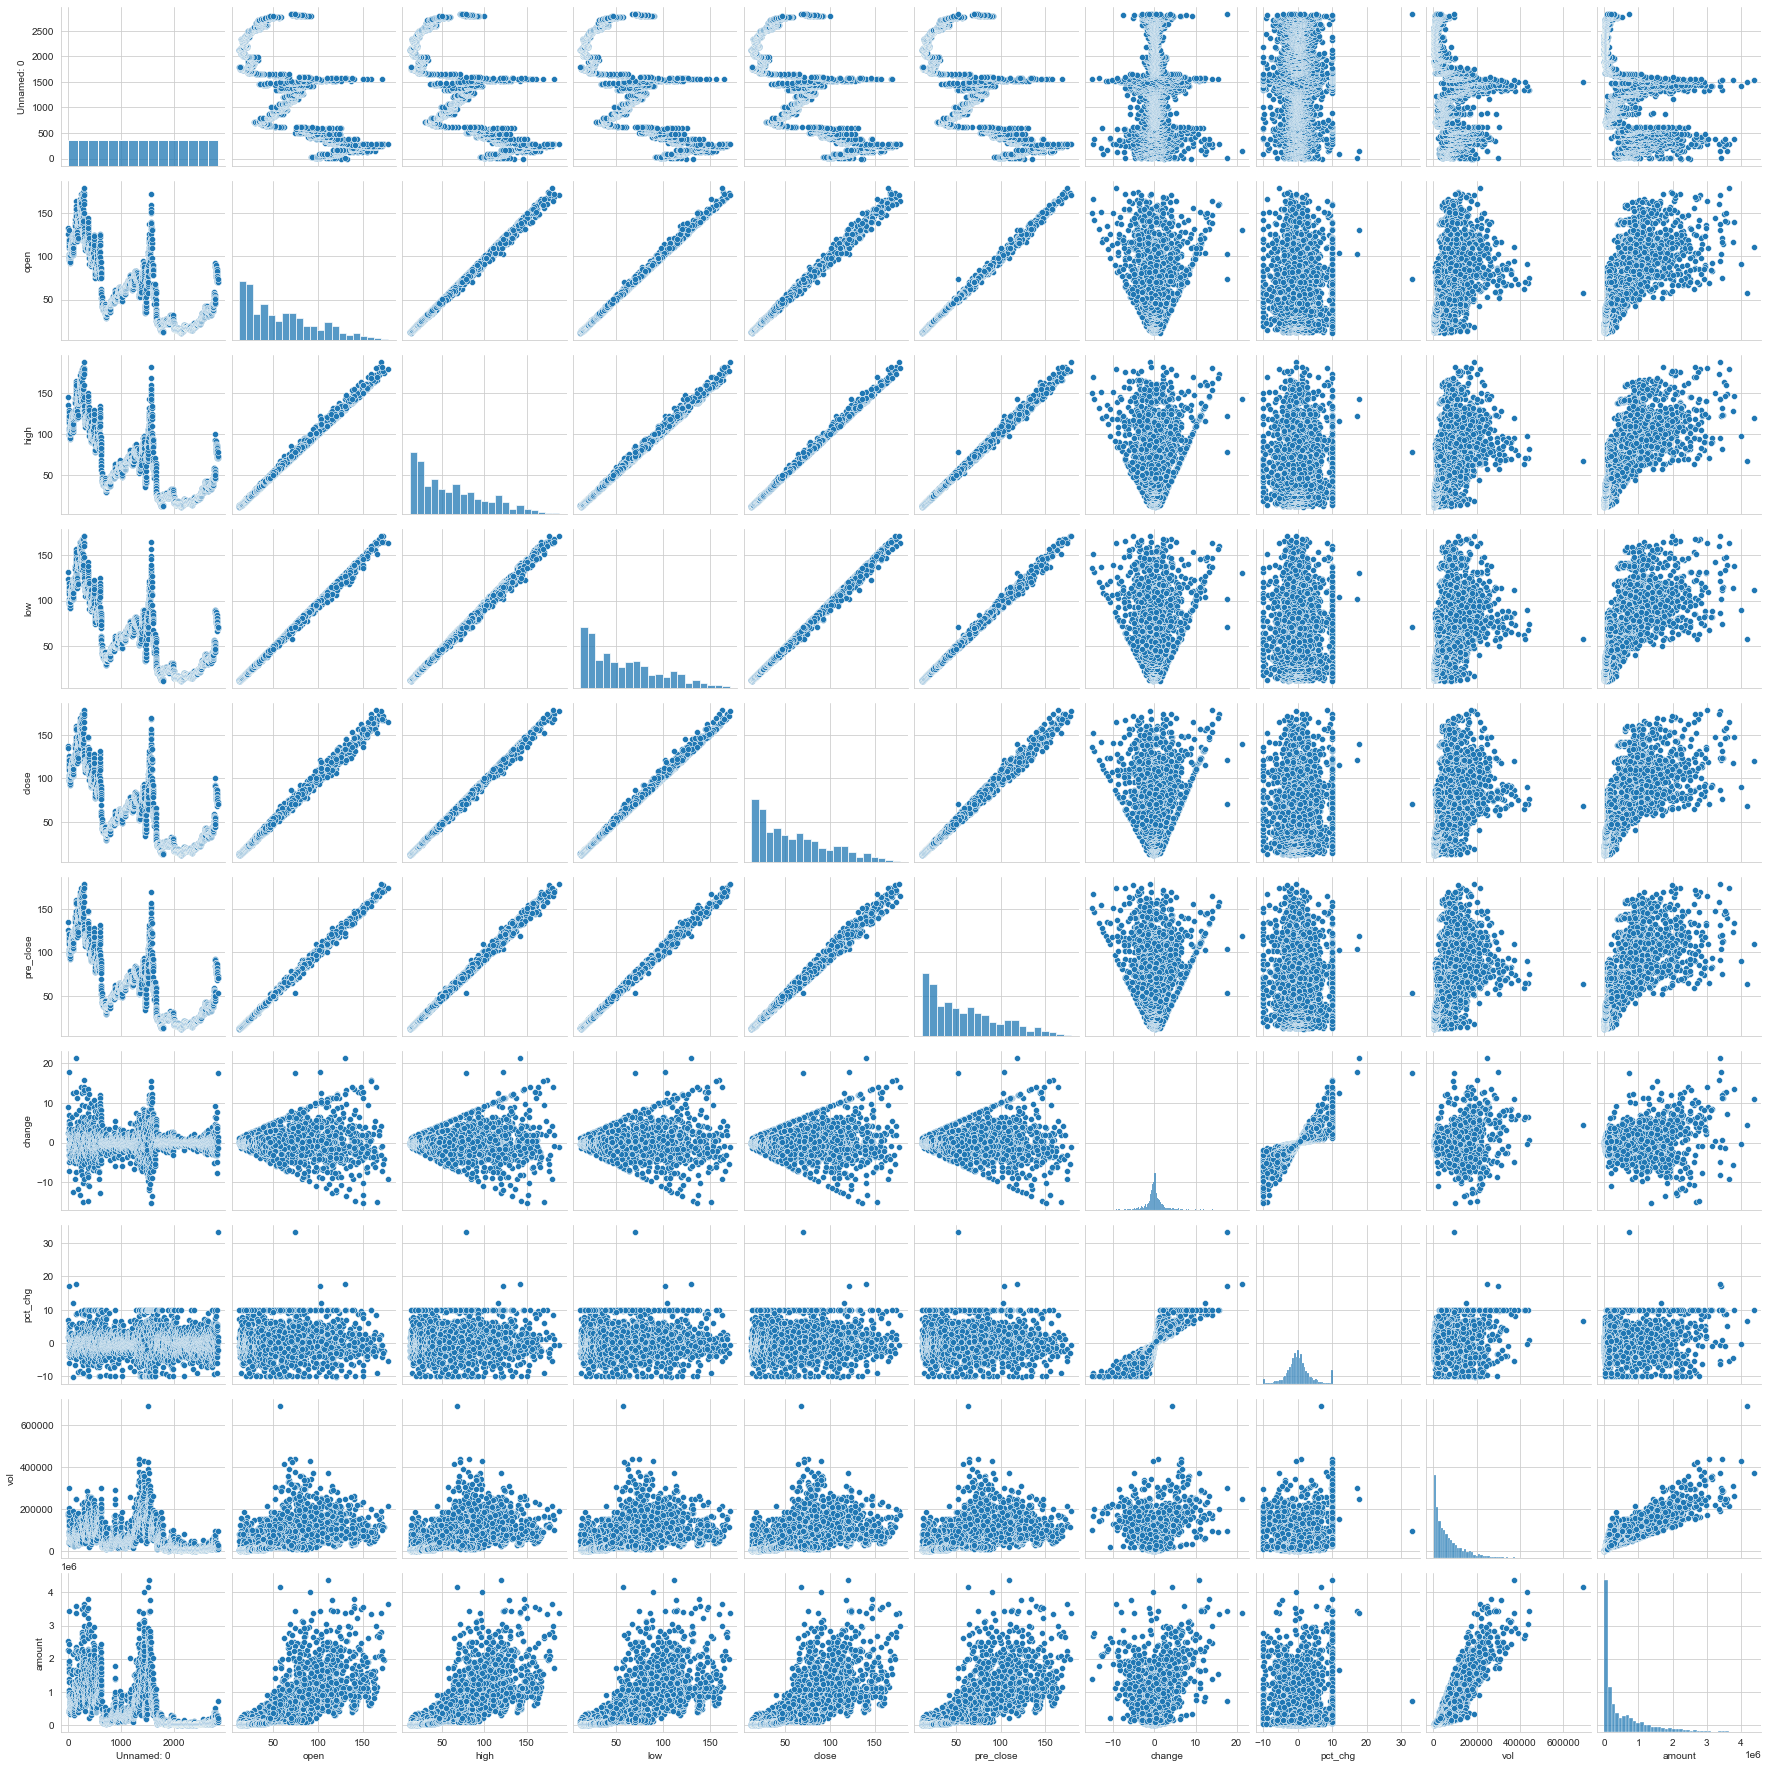

In [7]:
# for new data
sns.pairplot(ts_data)

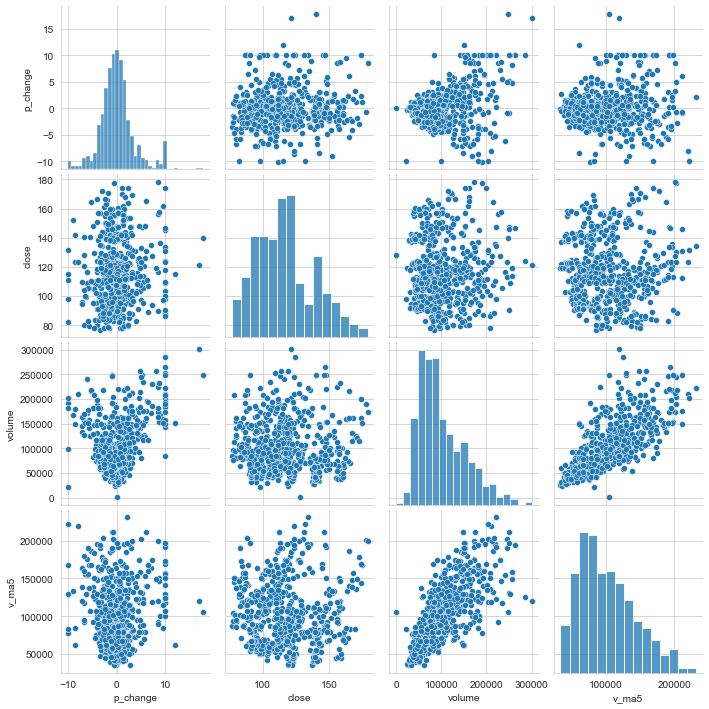

In [8]:
# for old data
sns.pairplot(ts_data_old)

In [9]:
# for new data
ts_data.hvplot.hist(by='pct_chg', subplots=False, width=1000)

:NdOverlay   [Element]
   :Histogram   [amount]   (amount_count)

In [10]:
# for old data
ts_data_old.hvplot.hist(by='p_change', subplots=False, width=1000)

:NdOverlay   [Element]
   :Histogram   [v_ma5]   (v_ma5_count)

In [11]:
# for new data
ts_data.hvplot.hist("pct_chg")

:Histogram   [pct_chg]   (pct_chg_count)

In [12]:
# for old data
ts_data_old.hvplot.hist("p_change")

:Histogram   [p_change]   (p_change_count)

In [13]:
# for new data
ts_data.hvplot.scatter(x='vol', y='pct_chg')

:Scatter   [vol]   (pct_chg)

In [14]:
# for old data
ts_data_old.hvplot.scatter(x='volume', y='p_change')

:Scatter   [volume]   (p_change)

In [15]:
# for new data
ts_data.hvplot.scatter(x='amount', y='pct_chg')

:Scatter   [amount]   (pct_chg)

In [16]:
# for old data
ts_data_old.hvplot.scatter(x='v_ma5', y='p_change')

:Scatter   [v_ma5]   (p_change)

In [17]:
ts_data.columns

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'pre_close', 'change',
       'pct_chg', 'vol', 'amount'],
      dtype='object')

In [18]:
ts_data_old.columns

Index(['p_change', 'close', 'volume', 'v_ma5'], dtype='object')

<AxesSubplot:>

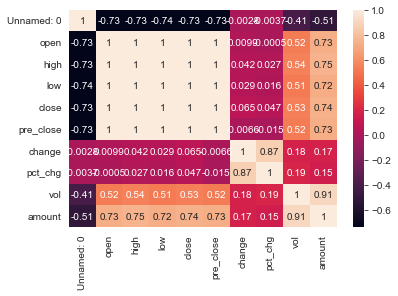

In [19]:
# for new data
sns.heatmap(ts_data.corr(), annot=True)

<AxesSubplot:>

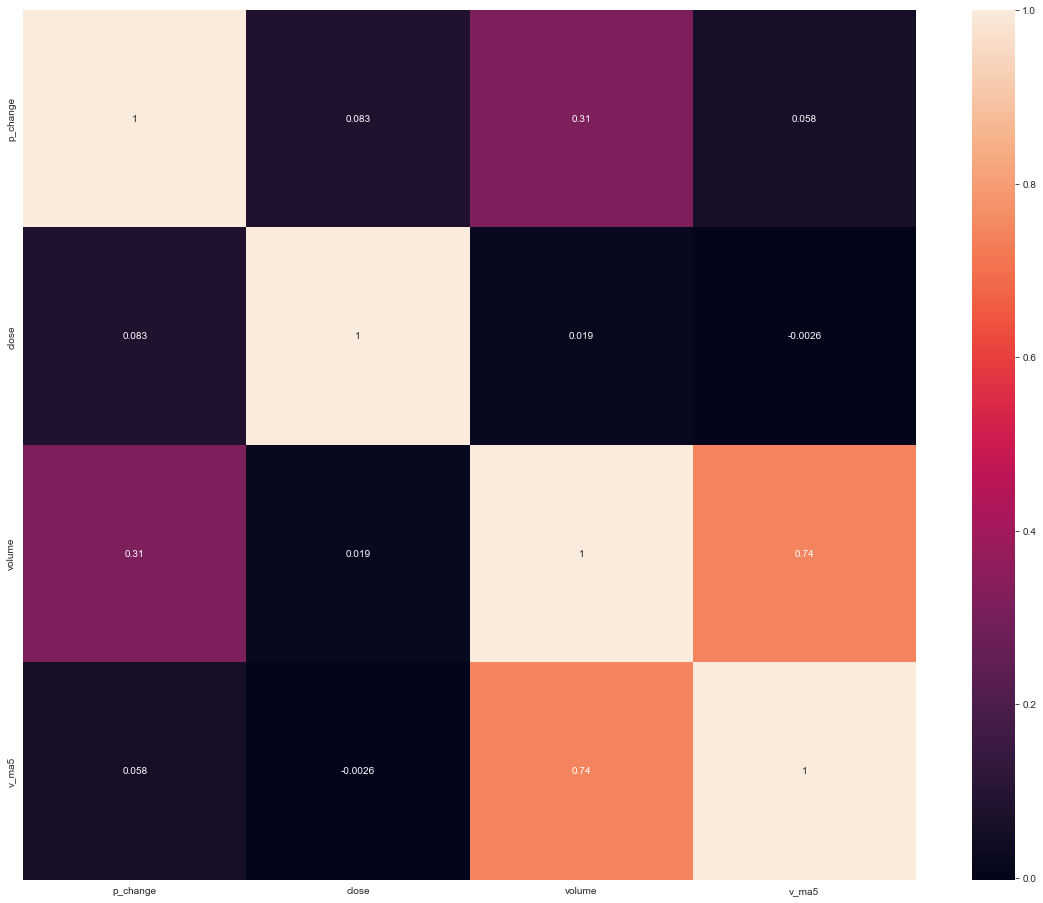

In [20]:
# for old data
plt.figure(figsize=(20, 16))
sns.heatmap(ts_data_old.corr(), annot=True)


# 📈 训练线性回归模型

> 现在让我们开始训练回归模型! 我们首先需要将数据分解为一个X数组(包含要进行训练的特性)和一个带有目标变量的y数组(在本例中是p_change列)。

## X and y arrays

In [21]:
X = ts_data_old[["close", "volume", "v_ma5"]]
y = ts_data_old['p_change']

## 🧱 Train Test Split

> 现在让我们将数据分解为一个训练集和一个测试集。我们将在训练集上训练出模型，然后使用测试集对模型进行评估。

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn import metrics
from sklearn.model_selection import cross_val_score

def cross_val(model):
    pred = cross_val_score(model, X, y, cv=10)
    return pred.mean()

def print_evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)
    print('__________________________________')

def evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    return mae, mse, rmse, r2_square

# 📦 为线性回归准备数据
> 已经对线性回归进行了大量的研究，并且有大量的文献说明必须如何构建数据以充分利用模型。

> 因此，当谈论这些要求和期望时，会有很多复杂的东西，这可能是令人生畏的。在实践中，在使用普通最小二乘回归(最常见的线性回归实现)时，您可以更多地将这些规则作为经验规则使用。

> 使用这些启发式方法尝试不同的数据准备，看看哪种方法最适合您的问题。
- **Linear Assumption.** 线性回归假设输入和输出之间的关系是线性的。它不支持其他任何东西。这可能是显而易见的，但当您有许多属性时，最好记住这一点。您可能需要转换数据以使关系线性化(例如，对数转换为指数关系)。
- **Remove Noise.** ：线性回归假设你的输入和输出变量没有噪声。考虑使用数据清理操作，以便更好地公开和澄清数据中的信号。这对于输出变量来说是最重要的，如果可能的话，您希望删除输出变量(y)中的异常值。
- **Remove Collinearity.** 当输入变量高度相关时，线性回归会过度拟合数据。考虑计算输入数据的成对相关性，并删除最相关的数据。
- **Gaussian Distributions.** 如果你的输入和输出变量是高斯分布，线性回归将会使预测更可靠。你可能会得到一些好处，使用变换(如对数或BoxCox)对你的变量，使他们的分布更高斯看起来
- **Rescale Inputs:** 如果您使用标准化或归一化来重新调整输入变量，线性回归通常会做出更可靠的预测。

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('std_scalar', StandardScaler())
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

# ✔️  线性回归 (Linear Regression)

In [25]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression(normalize=True)
lin_reg.fit(X_train,y_train)

LinearRegression(normalize=True)

## ✔️ 性能评估

In [26]:
# print the intercept
print(lin_reg.intercept_)

0.2482244897959185


In [27]:
coeff_df = pd.DataFrame(lin_reg.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
close,0.238105
volume,2.171091
v_ma5,-1.473922


## 系数解读：

## ✔️ 模型测试

看看模型在测试集的表现如何。

In [28]:
pred = lin_reg.predict(X_test)

In [29]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

**Residual Histogram**

In [30]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

## ✔️ 回归评价指标


采用回归问题的三个常见评估指标：

> - **平均绝对误差 (Mean Absolute Error, MAE):**
$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

> - **均方误差 (Mean Squared Error, MSE):**
$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

> - **均方根误差 (Root Mean Squared Error, RMSE):**
$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

> 📌 性能指标对比:
- **MAE** 最容易理解的，平均误差.
- **MSE** 常用的指标.
- **RMSE** 常用的指标.

> 均为损失函数，优化方案需要最小化它们。

In [31]:
test_pred = lin_reg.predict(X_test)
train_pred = lin_reg.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 2.2178438589876674
MSE: 10.250799018891506
RMSE: 3.201686902070767
R2 Square 0.1370779732869961
__________________________________
Train set evaluation:
_____________________________________
MAE: 2.27266452925939
MSE: 10.416056207392154
RMSE: 3.2273915485097486
R2 Square 0.17724745534216457
__________________________________


In [32]:
results_df = pd.DataFrame(data=[["Linear Regression", *evaluate(y_test, test_pred) , cross_val(LinearRegression())]],
                          columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,2.217844,10.250799,3.201687,0.137078,0.135694


# ✔️ 岭回归 Ridge Regression

> 源: [scikit-learn](http://scikit-learn.org/stable/modules/linear_model.html#ridge-regression)

> 岭回归通过对系数大小施加惩罚来解决最小二乘的过拟合问题.
>
> 目标函数：

$$\min_{w}\big|\big|Xw-y\big|\big|^2_2+\alpha\big|\big|w\big|\big|^2_2$$

***

In [33]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=100, solver='cholesky', tol=0.0001, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('====================================')
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 2.2443998891518366
MSE: 10.323516984265167
RMSE: 3.213023028903647
R2 Square 0.13095650568792994
__________________________________
Train set evaluation:
_____________________________________
MAE: 2.3105373318718287
MSE: 10.755512828529053
RMSE: 3.2795598528657854
R2 Square 0.1504341592845717
__________________________________


In [34]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

In [35]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

In [36]:
results_df_2 = pd.DataFrame(data=[["Ridge Regression", *evaluate(y_test, test_pred) , cross_val(Ridge())]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df = results_df.append(results_df_2, ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,2.217844,10.250799,3.201687,0.137078,0.135694
1,Ridge Regression,2.244400,10.323517,3.213023,0.130957,0.135694


# ✔️ 罗素回归 LASSO Regression

> 稀疏特征的线性模型。

> 数学上，它由以$\ell_1$范数为正则化器训练的线性模型.
>
> 目标函数为：

$$\min_{w}\frac{1}{2n_{samples}} \big|\big|Xw - y\big|\big|_2^2 + \alpha \big|\big|w\big|\big|_1$$
***

In [37]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1,
              precompute=True,
#               warm_start=True,
              positive=True,
              selection='random',
              random_state=42)
model.fit(X_train, y_train)

test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('====================================')
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 2.293251303041552
MSE: 10.595741085306747
RMSE: 3.255109995884432
R2 Square 0.10804042153117221
__________________________________
Train set evaluation:
_____________________________________
MAE: 2.393656252415802
MSE: 11.433947495989118
RMSE: 3.3814120565215235
R2 Square 0.09684536925474019
__________________________________


In [38]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

In [39]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

In [40]:
results_df_2 = pd.DataFrame(data=[["Lasso Regression", *evaluate(y_test, test_pred) , cross_val(Lasso())]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df = results_df.append(results_df_2, ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,2.217844,10.250799,3.201687,0.137078,0.135694
1,Ridge Regression,2.244400,10.323517,3.213023,0.130957,0.135694
2,Lasso Regression,2.293251,10.595741,3.255110,0.108040,0.137107


# ✔️ 弹性网络 Elastic Net

> 目标函数：

$$\min_{w}\frac{1}{2n_{samples}} \big|\big|Xw - y\big|\big|_2^2 + \alpha_1 \big|\big|w\big|\big|_1 + \alpha_2 \big|\big|w\big|\big|^2_2$$

***

In [41]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.9, selection='random', random_state=42)
model.fit(X_train, y_train)

test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('====================================')
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 2.219716716815874
MSE: 10.210295688719752
RMSE: 3.1953553305884075
R2 Square 0.14048758220587398
__________________________________
Train set evaluation:
_____________________________________
MAE: 2.2852635781462207
MSE: 10.50689521422126
RMSE: 3.24143412924299
R2 Square 0.17007218453575357
__________________________________


In [42]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

In [43]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

In [44]:
results_df_2 = pd.DataFrame(data=[["Elastic Net Regression", *evaluate(y_test, test_pred) , cross_val(ElasticNet())]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df = results_df.append(results_df_2, ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,2.217844,10.250799,3.201687,0.137078,0.135694
1,Ridge Regression,2.244400,10.323517,3.213023,0.130957,0.135694
2,Lasso Regression,2.293251,10.595741,3.255110,0.108040,0.137107
3,Elastic Net Regression,2.219717,10.210296,3.195355,0.140488,0.136496


# ✔️ Polynomial Regression
> 源: [scikit-learn](http://scikit-learn.org/stable/modules/linear_model.html#polynomial-regression-extending-linear-models-with-basis-functions)

***

> 机器学习中经常使用数据在非线性函数上训练的线性模型。
>
> 例如，可以构造多项式项来拓展线性回归的特征。在标准线性回归的情况下，二维数据模型可以是这样的:
>
$$\hat{y}(w, x) = w_0 + w_1 x_1 + w_2 x_2$$

> 但是如果使用抛物面而不是平面来拟合数据，就可以将二阶多项式的特征结合进来，构造如下所示的模型

$$\hat{y}(w, x) = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1 x_2 + w_4 x_1^2 + w_5 x_2^2$$

> 而且这依然可以是一个线性模型：可以构造这样一个新的特征维度

$$z = [x_1, x_2, x_1 x_2, x_1^2, x_2^2]$$

> 通过重新标记数据，模型可以被冲构成如式子

$$\hat{y}(w, x) = w_0 + w_1 z_1 + w_2 z_2 + w_3 z_3 + w_4 z_4 + w_5 z_5$$

> 我们可以看到，得到的多项式回归和线性模型是同类模型(即模型在w中是线性的)，并且可以用相同的技术求解。通过考虑在由这些基函数构建的高维空间中进行线性拟合。

***

In [45]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree=2)

X_train_2_d = poly_reg.fit_transform(X_train)
X_test_2_d = poly_reg.transform(X_test)

lin_reg = LinearRegression(normalize=True)
lin_reg.fit(X_train_2_d,y_train)

test_pred = lin_reg.predict(X_test_2_d)
train_pred = lin_reg.predict(X_train_2_d)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('====================================')
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 2.248440864291684
MSE: 10.886126571244711
RMSE: 3.299413064659336
R2 Square 0.08359549469260807
__________________________________
Train set evaluation:
_____________________________________
MAE: 2.1957932719757824
MSE: 9.668288436796734
RMSE: 3.1093871481043873
R2 Square 0.23631278907508735
__________________________________


In [46]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

In [47]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

In [48]:
results_df_2 = pd.DataFrame(data=[["Polynomail Regression", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = results_df.append(results_df_2, ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,2.217844,10.250799,3.201687,0.137078,0.135694
1,Ridge Regression,2.244400,10.323517,3.213023,0.130957,0.135694
2,Lasso Regression,2.293251,10.595741,3.255110,0.108040,0.137107
3,Elastic Net Regression,2.219717,10.210296,3.195355,0.140488,0.136496
4,Polynomail Regression,2.248441,10.886127,3.299413,0.083595,0.000000


# ✔️ 随机梯度下降 (Stochastic Gradient Descent)

> 梯度下降是一种非常通用的优化算法，能够找到最优的解决范围广泛的问题。梯度Sescent的一般思想是迭代地调整参数，以最小化代价函数。梯度下降是测量误差函数相对于参数向量的局部梯度，它沿着梯度下降的方向进行。一旦梯度为零，你就达到了最小值。

In [49]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(n_iter_no_change=250, penalty=None, eta0=0.0001, max_iter=100000)
sgd_reg.fit(X_train, y_train)

test_pred = sgd_reg.predict(X_test)
train_pred = sgd_reg.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('====================================')
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 2.287532205124874
MSE: 10.563413142015603
RMSE: 3.250140480350904
R2 Square 0.11076181859425438
__________________________________
Train set evaluation:
_____________________________________
MAE: 2.362249353863128
MSE: 11.257758475876326
RMSE: 3.3552583322117426
R2 Square 0.11076234145153896
__________________________________


In [50]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

In [51]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

In [52]:
results_df_2 = pd.DataFrame(data=[["Stochastic Gradient Descent", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = results_df.append(results_df_2, ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,2.217844,10.250799,3.201687,0.137078,0.135694
1,Ridge Regression,2.244400,10.323517,3.213023,0.130957,0.135694
2,Lasso Regression,2.293251,10.595741,3.255110,0.108040,0.137107
3,Elastic Net Regression,2.219717,10.210296,3.195355,0.140488,0.136496
4,Polynomail Regression,2.248441,10.886127,3.299413,0.083595,0.000000
5,Stochastic Gradient Descent,2.287532,10.563413,3.250140,0.110762,0.000000


# ✔️ 人工神经网络 (Artficial Neural Network)

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

model = Sequential()

model.add(Dense(X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1))

model.compile(optimizer=Adam(0.00001), loss='mse')

r = model.fit(X_train, y_train,
              validation_data=(X_test,y_test),
              batch_size=1,
              epochs=100)

Epoch 1/100
490/490 [==============================] - 1s 838us/step - loss: 12.7296 - val_loss: 11.8831
Epoch 2/100
490/490 [==============================] - 0s 767us/step - loss: 12.7189 - val_loss: 11.8851
Epoch 3/100
490/490 [==============================] - 0s 697us/step - loss: 12.7091 - val_loss: 11.8898

In [54]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

In [55]:
pd.DataFrame(r.history)

,loss,val_loss
0,12.729647,11.883060
1,12.718882,11.885117
2,12.709052,11.889825
3,12.696530,11.889823
4,12.687994,11.891765
...,...,...
95,11.485631,11.946113
96,11.449015,11.956894
97,11.445025,11.958946
98,11.394939,11.973983


In [56]:
pd.DataFrame(r.history).hvplot.line(y=['loss', 'val_loss'])

:NdOverlay   [Variable]
   :Curve   [index]   (value)

In [57]:
test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)

print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 2.379450709840692
MSE: 11.989227667499714
RMSE: 3.4625464137682997
R2 Square -0.009264606446379942
__________________________________
Train set evaluation:
_____________________________________
MAE: 2.397231255703891
MSE: 11.370728856331041
RMSE: 3.3720511348926845
R2 Square 0.10183893837657121
__________________________________


In [58]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

In [59]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

In [60]:
results_df_2 = pd.DataFrame(data=[["Artficial Neural Network", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = results_df.append(results_df_2, ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,2.217844,10.250799,3.201687,0.137078,0.135694
1,Ridge Regression,2.244400,10.323517,3.213023,0.130957,0.135694
2,Lasso Regression,2.293251,10.595741,3.255110,0.108040,0.137107
3,Elastic Net Regression,2.219717,10.210296,3.195355,0.140488,0.136496
4,Polynomail Regression,2.248441,10.886127,3.299413,0.083595,0.000000
5,Stochastic Gradient Descent,2.287532,10.563413,3.250140,0.110762,0.000000
6,Artficial Neural Network,2.379451,11.989228,3.462546,-0.009265,0.000000


# ✔️随机森林 （Random Forest Regression)

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=1000)
rf_reg.fit(X_train, y_train)

test_pred = rf_reg.predict(X_test)
train_pred = rf_reg.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)

print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 2.4957065040650406
MSE: 13.001179304868296
RMSE: 3.6057148119157034
R2 Square -0.09445165930385246
__________________________________
Train set evaluation:
_____________________________________
MAE: 0.850014612244896
MSE: 1.4712720690277454
RMSE: 1.2129600442833002
R2 Square 0.8837858768640762
__________________________________


In [62]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

In [63]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

In [64]:
results_df_2 = pd.DataFrame(data=[["Random Forest Regressor", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = results_df.append(results_df_2, ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,2.217844,10.250799,3.201687,0.137078,0.135694
1,Ridge Regression,2.244400,10.323517,3.213023,0.130957,0.135694
2,Lasso Regression,2.293251,10.595741,3.255110,0.108040,0.137107
3,Elastic Net Regression,2.219717,10.210296,3.195355,0.140488,0.136496
4,Polynomail Regression,2.248441,10.886127,3.299413,0.083595,0.000000
5,Stochastic Gradient Descent,2.287532,10.563413,3.250140,0.110762,0.000000
6,Artficial Neural Network,2.379451,11.989228,3.462546,-0.009265,0.000000
7,Random Forest Regressor,2.495707,13.001179,3.605715,-0.094452,0.000000


# ✔ 支持向量机 (Support Vector Machine)

In [65]:
from sklearn.svm import SVR

# svm_reg = SVR(kernel='rbf', C=1000000, epsilon=0.001)
# svm_reg.fit(X_train, y_train)
#
# test_pred = svm_reg.predict(X_test)
# train_pred = svm_reg.predict(X_train)
#
# print('Test set evaluation:\n_____________________________________')
# print_evaluate(y_test, test_pred)
#
# print('Train set evaluation:\n_____________________________________')
# print_evaluate(y_train, train_pred)

In [66]:
# pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')
#

In [67]:
# pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

In [68]:
# results_df_2 = pd.DataFrame(data=[["SVM Regressor", *evaluate(y_test, test_pred), 0]],
#                             columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
# results_df = results_df.append(results_df_2, ignore_index=True)
# results_df

# 📊 回归模型性能对比 (Models Comparison)

<AxesSubplot:ylabel='Model'>

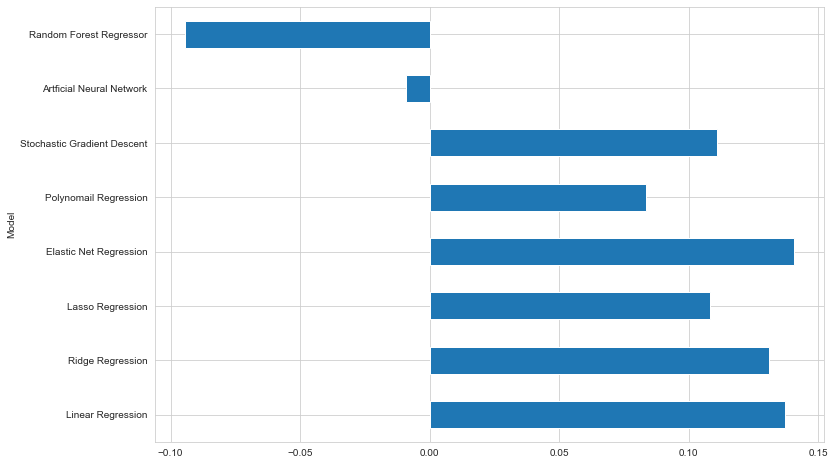

In [69]:
results_df.set_index('Model', inplace=True)
results_df['R2 Square'].plot(kind='barh', figsize=(12, 8))